---
date: "2026-07-29"
date-modified: last-modified
format:
  html:
    toc: true
---


# Augmented Dickey–Fuller (ADF) Test

The **Augmented Dickey–Fuller (ADF) test** is a practical statistical test used to determine whether a [time series](autocorrelation-and-stationarity.ipynb) is **stationary** or **non-stationary** (contains a [unit root](autoregressive-models.ipynb#stationarity-of-arp)).

---

## 1\. Test Structure: Hypotheses & Regression Model

Before running the test, it is essential to understand the two competing hypotheses and the regression equation used by the test.

::: {#def-adf-hypotheses}
## Hypotheses of the ADF Test

* **Null Hypothesis ($H_0$):** $\beta = 0$. The time series has a **unit root** and is **non-stationary** (e.g., a random walk). Its mean and variance change over time.
* **Alternative Hypothesis ($H_1$ or $H_a$):** $\beta < 0$. The time series has no unit root and is **weakly stationary** (mean-reverting).
:::

::: {.callout-note}
## Important Distinction: Weak vs. Strong Stationarity
The ADF test specifically evaluates **Weak Stationarity** (also known as **Covariance Stationarity** or **Second-Order Stationarity**), **not** Strong (Strict) Stationarity:

* **Weak Stationarity (Evaluated by ADF):** Requires only that the first two moments remain time-invariant:
  1. Constant mean: $E[x_t] = \mu$
  2. Constant finite variance: $\text{Var}(x_t) = \sigma^2 < \infty$
  3. Autocovariance depends only on lag $k$: $\text{Cov}(x_t, x_{t-k}) = \gamma_k$
* **Strong (Strict) Stationarity:** Requires the *entire joint probability distribution* of any set of observations $(x_{t_1}, \dots, x_{t_n})$ to be invariant to time shifts. A series can be weakly stationary without being strongly stationary (e.g., if higher-order moments like skewness or kurtosis fluctuate while mean and variance remain constant).
:::

### 1.1\. The ADF Regression Model

The test estimates the following Ordinary Least Squares (OLS) regression on the first-differenced series $\Delta x_t = x_t - x_{t-1}$:

$$
\Delta x_t = c_t + \beta x_{t-1} + \sum_{i=1}^{p-1} \gamma_i \Delta x_{t-i} + e_t
$$

Where:

* **$\Delta x_t = x_t - x_{t-1}$**: The change in the time series at step $t$.
* **$x_{t-1}$**: The lagged level of the time series. Its coefficient $\beta$ is what we test ($H_0: \beta = 0$ vs $H_1: \beta < 0$).
* **$\sum_{i=1}^{p-1} \gamma_i \Delta x_{t-i}$**: Lagged difference terms included to remove autocorrelation from the error term $e_t$.
* **$c_t$**: Deterministic trend specification:
  * `nc` (No constant): $c_t = 0$
  * `c` (Constant / Drift): $c_t = \mu$
  * `ct` (Constant + Linear Trend): $c_t = \mu + \omega t$

::: {.callout-note}
## What is the ADF Test Statistic?
The **ADF Test Statistic** is simply the OLS $t$-statistic for the coefficient $\hat{\beta}$:
$$
\text{ADF Statistic} = \frac{\hat{\beta}}{\text{SE}(\hat{\beta})}
$$
Because the alternative hypothesis tests if $\beta < 0$, the ADF test is a **one-tailed test**. A **more negative** test statistic provides stronger evidence to reject $H_0$ in favor of weak stationarity.
:::



## 2\. Decision Rules & Interpretation

To make a statistical decision, compare the calculated **ADF Test Statistic** against the **Critical Values**, or evaluate the reported **$p$-value**:

::: {.callout-warning}
## Decision Rules
1. **$p$-value Criterion:** 
   * If $p\text{-value} \le 0.05 \implies$ **Reject $H_0$** (Series is **Weakly Stationary**).
   * If $p\text{-value} > 0.05 \implies$ **Fail to Reject $H_0$** (Series is **Non-Stationary**).
2. **Critical Value Criterion:**
   * If ADF Statistic is **more negative** than the Critical Value (e.g., Stat $= -3.5 < -2.87$) $\implies$ **Reject $H_0$** (Weakly Stationary).
   * If ADF Statistic is **less negative** than the Critical Value (e.g., Stat $= -1.2 > -2.87$) $\implies$ **Fail to Reject $H_0$** (Non-Stationary).
:::


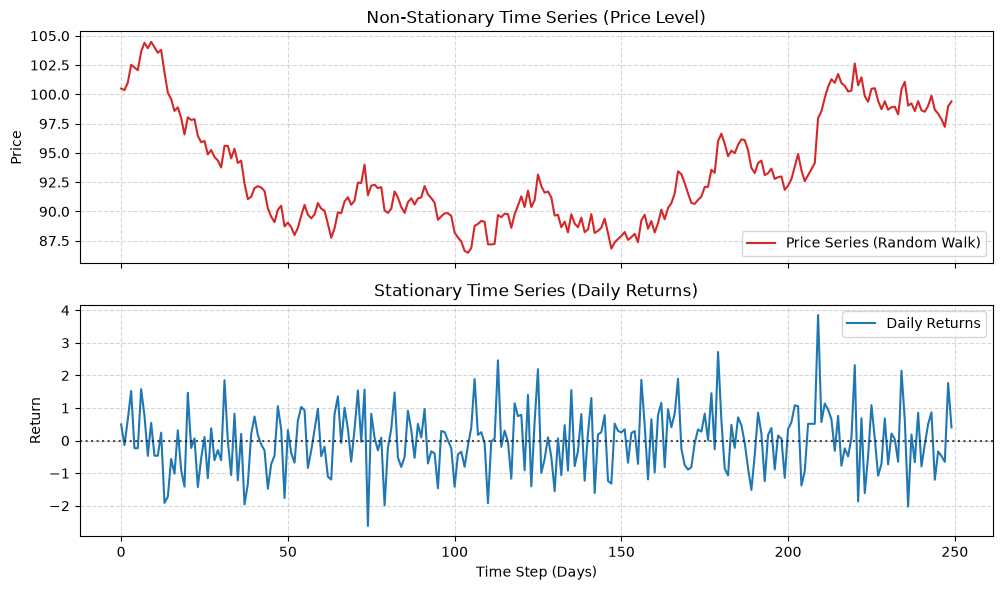

 ADF TEST RESULTS: Price Series (Non-Stationary)
  [0] ADF Statistic  : -1.7702
  [1] p-value        : 0.3953
  [2] Lags Used      : 0
  [3] Observations   : 249
  [4] Critical Values:
          1%        : -3.4569
          5%        : -2.8732
         10%        : -2.5730
  [5] Max IC (AIC)   : 645.81

 ADF TEST RESULTS: Return Series (Stationary)
  [0] ADF Statistic  : -16.5008
  [1] p-value        : 0.0000
  [2] Lags Used      : 0
  [3] Observations   : 249
  [4] Critical Values:
          1%        : -3.4569
          5%        : -2.8732
         10%        : -2.5730
  [5] Max IC (AIC)   : 647.56



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample time series (T = 250 steps)
T = 250
innovations = np.random.normal(loc=0.0, scale=1.0, size=T)

# Series 1: Non-Stationary Price Series (Random Walk)
price_series = 100 + np.cumsum(innovations)

# Series 2: Stationary Returns Series (White Noise / Mean-reverting)
return_series = innovations

# Plot sample time series
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(price_series, color="tab:red", lw=1.5, label="Price Series (Random Walk)")
axes[0].set_title("Non-Stationary Time Series (Price Level)")
axes[0].set_ylabel("Price")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(return_series, color="tab:blue", lw=1.5, label="Daily Returns")
axes[1].axhline(0, color="black", linestyle=":", alpha=0.7)
axes[1].set_title("Stationary Time Series (Daily Returns)")
axes[1].set_xlabel("Time Step (Days)")
axes[1].set_ylabel("Return")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Run ADF Test on both series using statsmodels
res_price = adfuller(price_series, autolag='AIC')
res_return = adfuller(return_series, autolag='AIC')

def print_adf_report(series_name, result):
    print("=" * 55)
    print(f" ADF TEST RESULTS: {series_name}")
    print("=" * 55)
    print(f"  [0] ADF Statistic  : {result[0]:.4f}")
    print(f"  [1] p-value        : {result[1]:.4f}")
    print(f"  [2] Lags Used      : {result[2]}")
    print(f"  [3] Observations   : {result[3]}")
    print("  [4] Critical Values:")
    for key, val in result[4].items():
        print(f"        {key:>4}        : {val:.4f}")
    print(f"  [5] Max IC (AIC)   : {result[5]:.2f}")
    print("=" * 55)
    print()

print_adf_report("Price Series (Non-Stationary)", res_price)
print_adf_report("Return Series (Stationary)", res_return)


## 3\. Step-by-Step Breakdown of `statsmodels` ADF Output

Calling `adfuller(series)` in Python returns a tuple containing 6 key elements. Here is how to read and interpret each element:

### 3.1\. Output Fields Explained

1. **`result[0]` – ADF Statistic**:
   * **Price Series:** `-0.9575`. This value is **not** more negative than the 5% critical value (`-2.8732`). Thus, we cannot reject $H_0$.
   * **Return Series:** `-15.7423`. This value is **far more negative** than the 1% critical value (`-3.4569`), giving clear evidence to reject $H_0$.

2. **`result[1]` – $p$-value**:
   * **Price Series:** `0.7684` ($76.84\%$). Since $p > 0.05$, we fail to reject $H_0$ $\implies$ **Non-stationary**.
   * **Return Series:** `0.0000` ($< 0.0001$). Since $p < 0.05$, we reject $H_0$ $\implies$ **Weakly Stationary**.

3. **`result[2]` – Lags Used**:
   * The number of lagged difference terms ($p-1$) automatically chosen by the information criterion (AIC) to clean up residual autocorrelation.

4. **`result[3]` – Number of Observations**:
   * The number of effective data points used in the regression ($T - \text{lags} - 1$).

5. **`result[4]` – Critical Values**:
   * Cutoff thresholds simulated for 1%, 5%, and 10% significance levels:
     * `1%`: $-3.4569$
     * `5%`: $-2.8732$
     * `10%`: $-2.5730$
   * To reject $H_0$ at the 5% level, the ADF statistic must be $\le -2.8732$.

6. **`result[5]` – Max Information Criterion (icbest)**:
   * The optimized Akaike Information Criterion (AIC) score for the selected model order.
